In [1]:
# -------------------------
# a) Naive Perceptron
# -------------------------

def H(z):
    """Heaviside step function"""
    return 1 if z >= 0 else 0


def output(x1, x2, w1, w2, b):
    """Compute perceptron output"""
    z = w1 * x1 + w2 * x2 + b
    return H(z)


def p_learn(X, Y, w1, w2, b, eta, epochs=10):
    """Perceptron learning algorithm"""
    for epoch in range(epochs):
        for i in range(len(X)):
            x1, x2 = X[i]
            y = Y[i]

            y_pred = output(x1, x2, w1, w2, b)
            error = y - y_pred

            # update rule
            w1 += eta * error * x1
            w2 += eta * error * x2
            b += eta * error

    return w1, w2, b


# Test OR dataset
X = [[1, 1], [1, 0], [0, 1], [0, 0]]
Y_OR = [1, 1, 1, 0]

w1, w2, b = p_learn(X, Y_OR, 0, 0, 0, eta=0.1)
print("Naive Weights:", w1, w2, b)

Naive Weights: 0.1 0.1 -0.1


Matplotlib is building the font cache; this may take a moment.


NumPy Weights: [0.1 0.1] -0.1


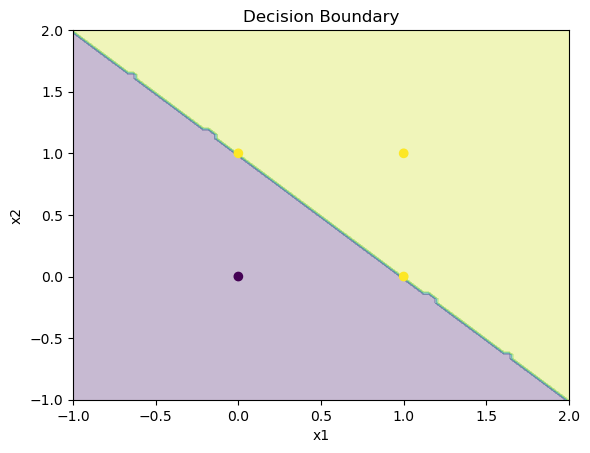

In [2]:
# -------------------------
# b) NumPy Implementation
# -------------------------

import numpy as np
import matplotlib.pyplot as plt


def H(z):
    return np.where(z >= 0, 1, 0)


def output(x, w, b):
    return H(np.dot(w, x) + b)


def p_learn(X, Y, w, b, eta, epochs):
    for _ in range(epochs):
        for x, y in zip(X, Y):
            y_pred = output(x, w, b)
            error = y - y_pred

            w = w + eta * error * x
            b = b + eta * error

    return w, b


def plot_decision_boundary(X, Y, w, b):
    X = np.array(X)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = H(w[0] * xx + w[1] * yy + b)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.title("Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


# Test OR dataset
X = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
Y_OR = np.array([1, 1, 1, 0])

w = np.zeros(2)
b = 0

w, b = p_learn(X, Y_OR, w, b, eta=0.1, epochs=10)

print("NumPy Weights:", w, b)
plot_decision_boundary(X, Y_OR, w, b)


OR Weights: [0.1 0.1] Bias: -0.1


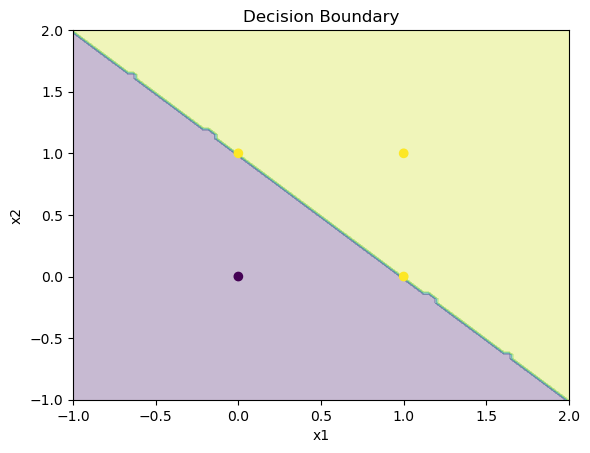


AND Weights: [0.1 0.2] Bias: -0.20000000000000004


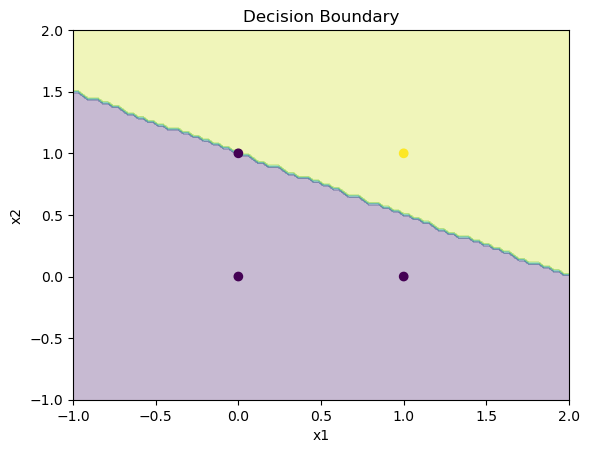


NAND Weights: [-0.1 -0.2] Bias: 0.2


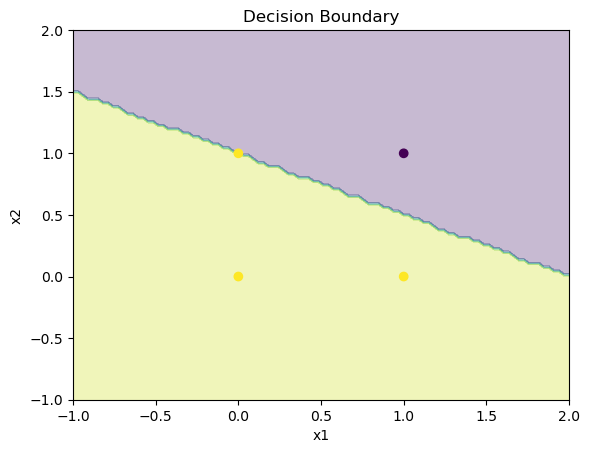

In [3]:
# -------------------------
# c) OOP Perceptron
# -------------------------

class Perceptron:
    def __init__(self, n_inputs):
        self.n_inputs = n_inputs
        self.weights = np.zeros(n_inputs)
        self.bias = 0

    def out(self, X):
        return H(np.dot(self.weights, X) + self.bias)

    def learn(self, data_learn, eta, epochs):
        for _ in range(epochs):
            for x, y in data_learn:
                y_pred = self.out(x)
                error = y - y_pred

                self.weights += eta * error * x
                self.bias += eta * error


# Test datasets
X = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])

Y_OR = np.array([1, 1, 1, 0])
Y_AND = np.array([1, 0, 0, 0])
Y_NAND = np.array([0, 1, 1, 1])


def test_model(Y, name):
    model = Perceptron(n_inputs=2)
    data = list(zip(X, Y))

    model.learn(data, eta=0.1, epochs=10)

    print(f"\n{name} Weights:", model.weights, "Bias:", model.bias)
    plot_decision_boundary(X, Y, model.weights, model.bias)


# Run tests
test_model(Y_OR, "OR")
test_model(Y_AND, "AND")
test_model(Y_NAND, "NAND")